<a href="https://colab.research.google.com/github/jeromenazario/linear-regression-activity/blob/main/Linear_Regression_Typing_Speed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Model — Typing Practice vs. Typing Speed
**Name:** Jerome Nazario

**Independent Variable:** Weekly Practice Hours (hours/week)

**Dependent Variable:** Typing Speed (words per minute / WPM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset from GitHub raw CSV link
url = "https://raw.githubusercontent.com/jeromenazario/linear-regression-activity/refs/heads/main/typing_speed_dataset.csv"
df = pd.read_csv(url)

print("Dataset Preview:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nDescriptive Statistics:")
print(df.describe())

Dataset Preview:
   practice_hours_per_week  typing_speed_wpm
0                      8.1              46.6
1                     19.1              96.6
2                     14.9              80.3
3                     12.4              77.4
4                      4.0              38.5
5                      4.0              28.0
6                      2.1              30.4
7                     17.5              91.6
8                     12.4              68.7
9                     14.5              84.0

Shape: (60, 2)

Descriptive Statistics:
       practice_hours_per_week  typing_speed_wpm
count                60.000000         60.000000
mean                  9.890000         61.116667
std                   5.799085         24.203104
min                   1.400000         24.300000
25%                   4.500000         41.125000
50%                   9.550000         59.000000
75%                  14.600000         79.850000
max                  19.400000        106.100000


**Description:** Importing libraries gives us the mathematical and visualization tools needed to build and evaluate the model. Loading the dataset is the essential first step — without data, the model has nothing to learn from.

In [2]:
# PREPARE VARIABLES FOR MODELING
X = df[["practice_hours_per_week"]]  # 2D array required by sklearn
y = df["typing_speed_wpm"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\nSample X values:\n{X.head()}")
print(f"\nSample y values:\n{y.head()}")

Training samples : 48
Testing  samples : 12

Sample X values:
   practice_hours_per_week
0                      8.1
1                     19.1
2                     14.9
3                     12.4
4                      4.0

Sample y values:
0    46.6
1    96.6
2    80.3
3    77.4
4    38.5
Name: typing_speed_wpm, dtype: float64


**Description:** Separating X and y tells the model which column is the input (cause) and which is the output (effect). Splitting into train/test sets allows us to evaluate the model fairly on data it has never seen before.

In [7]:
# FIT THE LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)

print("Model successfully fitted!")
print(f"Training R\u00b2 score: {model.score(X_train, y_train):.4f}")

Model successfully fitted!
Training R² score: 0.9650


**Description:** Fitting the model finds the best-fit line through the training data by minimizing prediction error. This is the core step where the model learns the relationship between practice hours and typing speed.

In [4]:
# EXTRACT AND INTERPRET MODEL PARAMETERS
slope     = model.coef_[0]
intercept = model.intercept_

print(f"Slope (coefficient) : {slope:.4f} WPM per hour/week")
print(f"Intercept           : {intercept:.4f} WPM")
print(f"\nEquation: Typing Speed = {slope:.2f} \u00d7 Practice Hours + {intercept:.2f}")

Slope (coefficient) : 4.0648 WPM per hour/week
Intercept           : 21.3862 WPM

Equation: Typing Speed = 4.06 × Practice Hours + 21.39


**Description:** The slope tells us how much typing speed (WPM) increases for every additional hour of practice per week. The intercept is the predicted speed when practice hours = 0. Together they define the full regression equation.

In [5]:
# EVALUATE MODEL PERFORMANCE
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"R\u00b2 Score                 : {r2:.4f}")
print(f"\nInterpretation:")
print(f"  \u2192 The model explains {r2*100:.1f}% of the variance in typing speed.")
print(f"  \u2192 On average, predictions are off by ~{mse**0.5:.2f} WPM (RMSE).")

Mean Squared Error (MSE) : 16.6506
R² Score                 : 0.9697

Interpretation:
  → The model explains 97.0% of the variance in typing speed.
  → On average, predictions are off by ~4.08 WPM (RMSE).


**Description:** MSE measures the average squared difference between actual and predicted values — lower is better. R² tells us what proportion of the variation in typing speed is explained by practice hours — a value close to 1.0 indicates an excellent fit.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


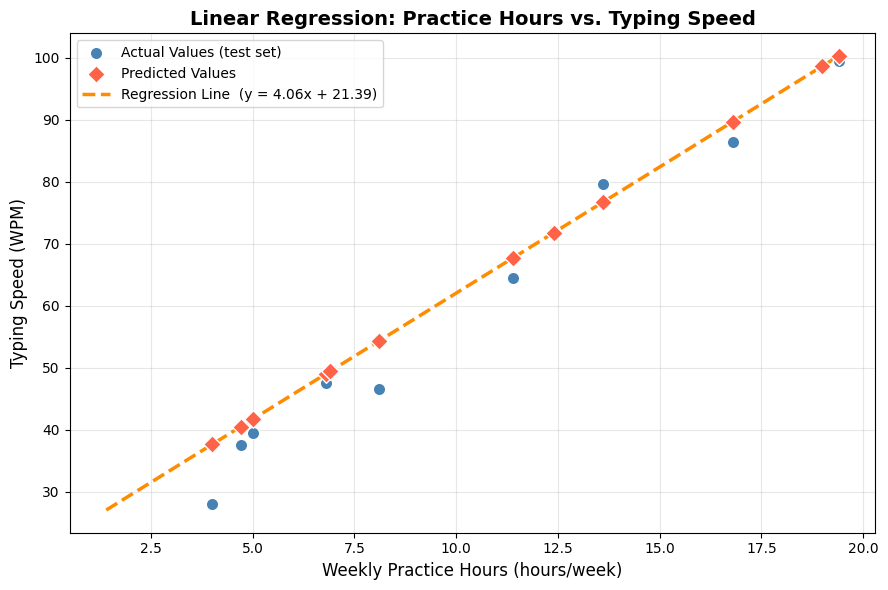

In [6]:
# DISPLAY ACTUAL VS. PREDICTED VALUES
X_line = np.linspace(X.min().values[0], X.max().values[0], 200).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(9, 6))

plt.scatter(X_test, y_test,
            color="steelblue", edgecolors="white", s=80, zorder=3,
            label="Actual Values (test set)")

plt.scatter(X_test, y_pred,
            color="tomato", edgecolors="white", s=80, marker="D", zorder=3,
            label="Predicted Values")

plt.plot(X_line, y_line,
         color="darkorange", linewidth=2.5, linestyle="--",
         label=f"Regression Line  (y = {slope:.2f}x + {intercept:.2f})")

plt.xlabel("Weekly Practice Hours (hours/week)", fontsize=12)
plt.ylabel("Typing Speed (WPM)", fontsize=12)
plt.title("Linear Regression: Practice Hours vs. Typing Speed", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()